# Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
from ICU_helpers.data_cleaning import *
from ICU_helpers.surgery_mapping import *

# Import data

In [2]:
df = pd.read_excel("../Nkhoma_data/ICU_research.xlsx")

# Clean Data

In [3]:
df = (
    df
    .pipe(to_snake_case)
    .pipe(drop_empty_rows)
    .pipe(drop_unnamed_index)
    .pipe(format_dates)
    .pipe(format_gender)
    .pipe(format_age)
    .pipe(format_stay_durations)
    .pipe(format_intubation)
    .pipe(format_qsofa)
    .pipe(format_categoricals)
    .pipe(add_derived_columns)
    .pipe(map_surgeries)
)

In [4]:
df.columns

Index(['year_of_birth', 'gender', 'hospital_admission_date',
       'hospital_discharge_date', 'date_of_surgery', 'type_of_surgery',
       'icu_admission_date', 'icu_discharge_date', 'intubation',
       'date_of_intubation', 'date_of_extubation', 'niv', 'type_of_admission',
       'lead_department', 'reason_for_admission_category',
       'reason_for_admission_comment', 'diagnosis_that_lead_to_admission',
       'other_diagnoses', 'other_diagnoses_free_text',
       'disability_at_discharge', 'cause_of_death', 'discharge_to', 'qsofa',
       'length_of_icu_stay_nights', 'intubation_nights',
       'hospital_stay_nights', 'discharge_after_icu_nights', 'age_years',
       'comment', 'icu_stay_check', 'hosp_stay_check',
       'type_of_surgery_grouped'],
      dtype='object')

In [5]:
df.type_of_surgery_grouped.unique()

array(['Hemi/Total Thyroidectomy', 'Other', 'EGD', 'Chest Tube Placement',
       'Exploratory Laparotomy', 'No Surgery', 'Hysterectomy',
       'Open Prostatectomy',
       'Exploratory Laparotomy with Bowel Resection', 'Debridement',
       'Caesarean Section', 'Laparoscopic Cholecystectomy', nan,
       'Exploratory Laparotomy with Splenectomy'], dtype=object)

In [6]:
df

,year_of_birth,gender,hospital_admission_date,hospital_discharge_date,date_of_surgery,type_of_surgery,icu_admission_date,icu_discharge_date,intubation,date_of_intubation,...,qsofa,length_of_icu_stay_nights,intubation_nights,hospital_stay_nights,discharge_after_icu_nights,age_years,comment,icu_stay_check,hosp_stay_check,type_of_surgery_grouped
0,1944.0,Male,2023-07-24,2023-07-27,2023-07-26,Hemithyroidectomy,2023-07-25,2023-07-26,Yes,2023-07-26,...,<NA>,1.0,0.0,3.0,1.0,79,NaN,False,False,Hemi/Total Thyroidectomy
1,1988.0,Male,2023-07-14,2023-08-21,2023-08-17,Buccal Graft Urethroplasty,2023-08-17,2023-08-20,Yes,2023-08-17,...,<NA>,3.0,1.0,38.0,1.0,35,NaN,False,False,Other
2,1977.0,Female,2023-08-12,2023-08-18,NaT,EGD,2023-08-17,2023-08-18,No,NaT,...,3,1.0,0.0,6.0,0.0,46,NaN,False,False,EGD
3,2010.0,Female,2023-07-31,2023-08-08,2023-07-31,Chest Tube Placement,2023-07-31,2023-08-05,No,NaT,...,<NA>,5.0,0.0,8.0,3.0,13,NaN,False,False,Chest Tube Placement
4,1972.0,Male,2023-08-10,2023-08-12,2023-08-10,EGD And Banding,2023-08-10,2023-08-11,No,NaT,...,<NA>,1.0,0.0,2.0,1.0,51,NaN,False,False,EGD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,2006.0,Male,2024-12-06,2024-12-09,NaT,No Surgery,2024-12-06,2024-12-07,No,NaT,...,<NA>,1.0,0.0,3.0,2.0,17,NaN,False,False,No Surgery
143,2005.0,Female,2024-12-21,2024-12-28,2024-12-23,Ex Lap,2024-12-23,2024-12-24,Yes,NaT,...,<NA>,1.0,0.0,7.0,4.0,18,NaN,False,False,Exploratory Laparotomy
144,2002.0,Female,2024-12-23,2024-12-26,2024-12-24,Cessarian Section,2024-12-23,2024-12-26,No,NaT,...,1,3.0,0.0,3.0,0.0,21,NaN,False,False,Caesarean Section
145,2022.0,Male,2024-12-27,2024-12-29,2024-12-29,NaN,2024-12-27,2024-12-29,No,NaT,...,2,2.0,0.0,2.0,0.0,1,NaN,False,False,NaN


# ICU Data Assessment
**Date:** 05.05.2026  
**Patients:** 141 admissions (2023–2024)

In [7]:
df['lead_department'] = df['lead_department'].str.strip().str.replace(' ', '_')
df = df[df['age_years'].between(0, 150)]
df = df.copy()

df['died_on_icu'] = df['discharge_to'] == 'Death'
df['was_intubated'] = df['intubation'] == 'Yes'

df['discharge_category'] = df['discharge_to'].map({
    'Ward': 'Ward',
    'Death': 'Death',
    'Kch': 'Referral',
    'Home': 'Home'
}).fillna('Unknown')

def intubation_group(row):
    if row['intubation'] == 'No':
        return 'Not intubated'
    elif pd.notna(row['date_of_intubation']) and row['date_of_intubation'] >= row['icu_admission_date']:
        return 'Intubated on ICU'
    else:
        return 'Intubated outside ICU'

df['intubation_group'] = df.apply(intubation_group, axis=1)

print(f"Shape: {df.shape}")

Shape: (141, 36)


## 1. Bed Occupancy
How many days had 0, 1, 2, 3, or 4+ ICU beds occupied simultaneously?  
Calculated by counting patients where `icu_admission_date ≤ day ≤ icu_discharge_date`.

In [8]:
import pandas as pd

all_days = pd.date_range(
    start=df['icu_admission_date'].min(),
    end=df['icu_discharge_date'].max(),
    freq='D'
)

def count_occupied(day):
    return ((df['icu_admission_date'] <= day) & (df['icu_discharge_date'] >= day)).sum()

occupancy = pd.Series({day: count_occupied(day) for day in all_days}, name='beds_occupied')
occ_dist = occupancy.value_counts().sort_index()
print(occ_dist)

beds_occupied
0    230
1    187
2     82
3     22
4      4
Name: count, dtype: int64


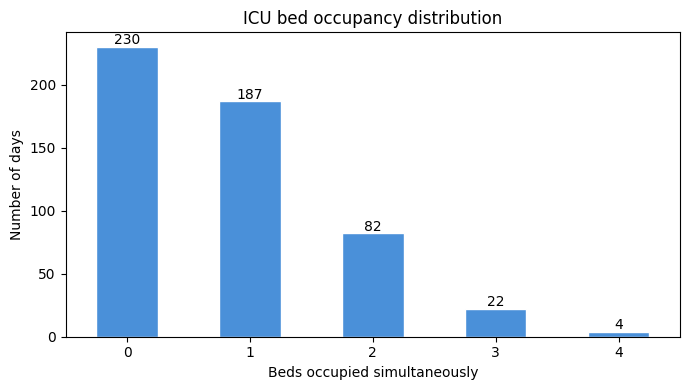

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
occ_dist.plot(kind='bar', ax=ax, color='#4a90d9', edgecolor='white')
ax.set_xlabel('Beds occupied simultaneously')
ax.set_ylabel('Number of days')
ax.set_title('ICU bed occupancy distribution')
ax.set_xticklabels(occ_dist.index, rotation=0)
for i, v in enumerate(occ_dist):
    ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 2. Deaths by Department
Per reporting convention: a surgical patient who died on the ICU counts as a surgical death.  
This shows what percentage of each department's total ICU patients died on the ICU.

In [10]:
dept_summary = df.groupby('lead_department').agg(
    total_patients=('died_on_icu', 'count'),
    icu_deaths=('died_on_icu', 'sum')
).assign(
    mortality_pct=lambda x: (x['icu_deaths'] / x['total_patients'] * 100).round(1)
).sort_values('mortality_pct', ascending=False)

dept_summary

,total_patients,icu_deaths,mortality_pct
lead_department,,,
Pediatrics,7,2,28.6
Internal_Medicine,20,5,25.0
Gen_Surg,83,16,19.3
Gen_Surg_Trauma,17,2,11.8
Obs_Gyn,14,0,0.0


## 3. Visualisations

### 3a. Intubation status

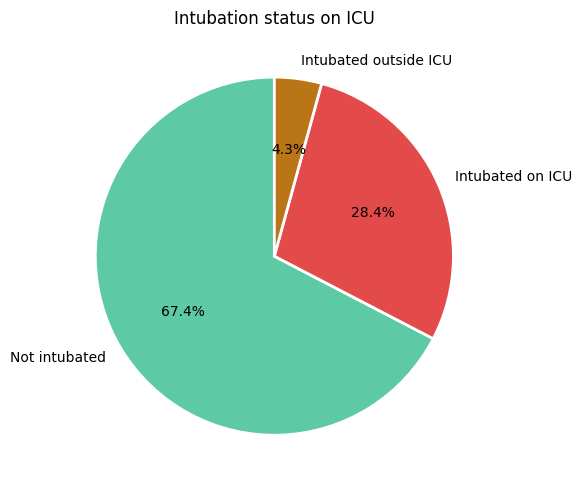

intubation_group
Not intubated            95
Intubated on ICU         40
Intubated outside ICU     6
Name: count, dtype: int64


In [11]:
intub_counts = df['intubation_group'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
colors = ['#5dcaa5', '#e24b4a', '#ba7517']
wedges, texts, autotexts = ax.pie(
    intub_counts,
    labels=intub_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('Intubation status on ICU')
plt.tight_layout()
plt.show()

print(intub_counts)

### 3b. ICU patients per department

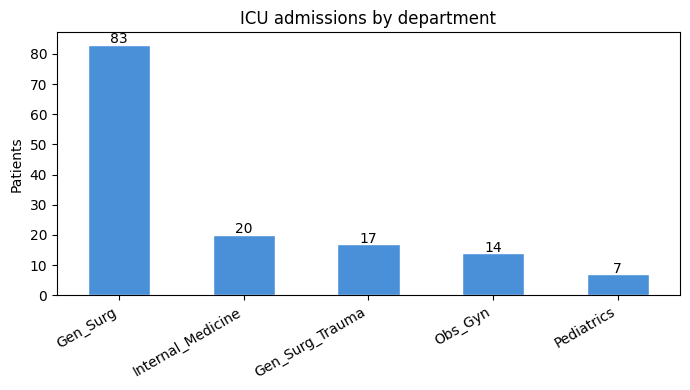

In [12]:
dept_counts = df['lead_department'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
dept_counts.plot(kind='bar', ax=ax, color='#4a90d9', edgecolor='white')
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.set_title('ICU admissions by department')
ax.set_xticklabels(dept_counts.index, rotation=30, ha='right')
for i, v in enumerate(dept_counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 3c. Procedures and ICU stay

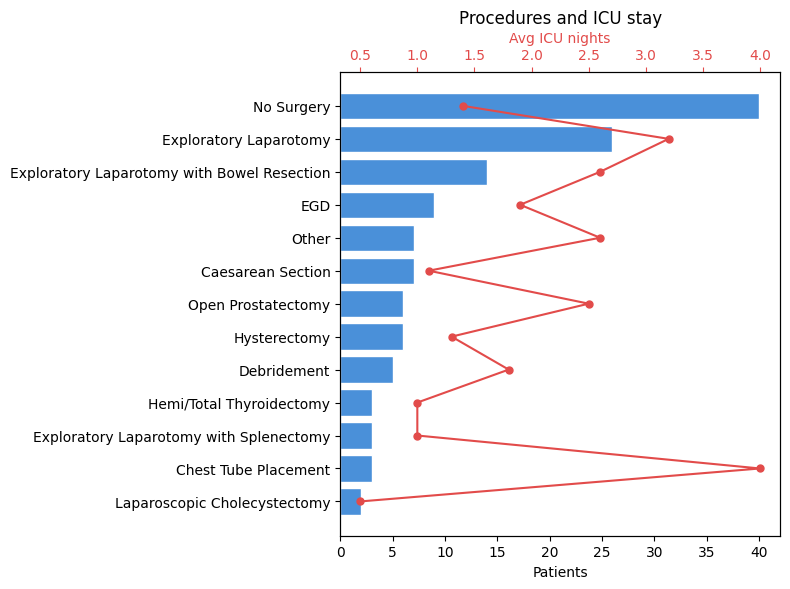

In [13]:
proc = df.groupby('type_of_surgery_grouped').agg(
    patients=('type_of_surgery_grouped', 'count'),
    avg_icu_nights=('length_of_icu_stay_nights', 'mean')
).sort_values('patients', ascending=True).round(1)

fig, ax1 = plt.subplots(figsize=(8, 6))
bars = ax1.barh(proc.index, proc['patients'], color='#4a90d9', edgecolor='white')
ax1.set_xlabel('Patients')
ax1.set_title('Procedures and ICU stay')

ax2 = ax1.twiny()
ax2.plot(proc['avg_icu_nights'], proc.index, 'o-', color='#e24b4a', linewidth=1.5, markersize=5)
ax2.set_xlabel('Avg ICU nights', color='#e24b4a')
ax2.tick_params(axis='x', colors='#e24b4a')

plt.tight_layout()
plt.show()

### 3d. ICU discharge destinations

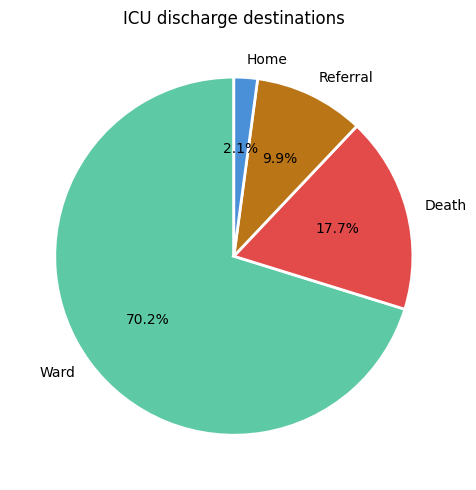

discharge_category
Ward        99
Death       25
Referral    14
Home         3
Name: count, dtype: int64


In [14]:
discharge_counts = df['discharge_category'].value_counts()
colors = {'Ward': '#5dcaa5', 'Death': '#e24b4a', 'Referral': '#ba7517', 'Home': '#4a90d9', 'Unknown': '#888780'}

fig, ax = plt.subplots(figsize=(6, 5))
wedges, texts, autotexts = ax.pie(
    discharge_counts,
    labels=discharge_counts.index,
    autopct='%1.1f%%',
    colors=[colors.get(k, '#888780') for k in discharge_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title('ICU discharge destinations')
plt.tight_layout()
plt.show()

print(discharge_counts)

## 4. Patterns in the Data

### 4a. ICU length of stay by intubation group

                       count  mean  median   Q1   Q3   max
intubation_group                                          
Intubated on ICU        40.0   2.9     1.5  1.0  3.0  17.0
Intubated outside ICU    6.0   2.0     2.0  1.2  2.8   3.0
Not intubated           95.0   1.7     1.0  1.0  2.0  12.0


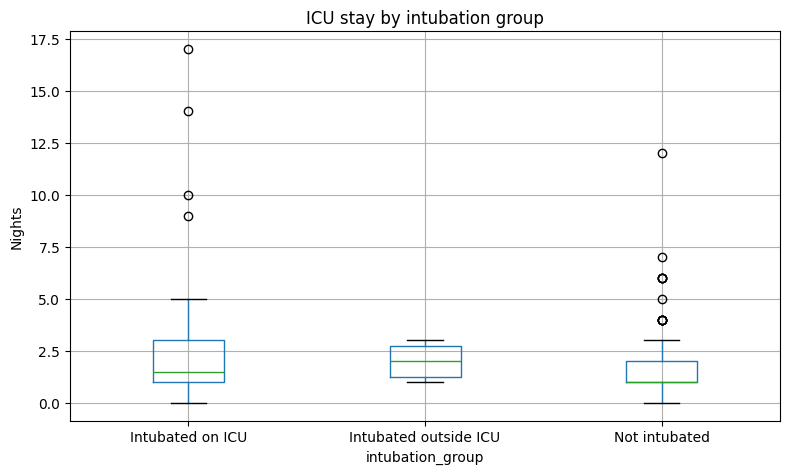

In [15]:
print(df.groupby('intubation_group')['length_of_icu_stay_nights']
      .describe()[['count','mean','50%','25%','75%','max']]
      .round(1).rename(columns={'50%':'median','25%':'Q1','75%':'Q3'}))

df.boxplot(column='length_of_icu_stay_nights', by='intubation_group', figsize=(8, 5))
plt.title('ICU stay by intubation group')
plt.suptitle('')
plt.ylabel('Nights')
plt.tight_layout()
plt.show()

### 4b. Mortality by intubation group
Non-intubated patients had the highest mortality — likely reflecting late presentations and palliated cases.

                       patients  deaths  mortality_pct
intubation_group                                      
Intubated on ICU             40       4           10.0
Intubated outside ICU         6       1           16.7
Not intubated                95      20           21.1


/tmp/ipykernel_4022/2063793476.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mort_intub.index, rotation=15, ha='right')


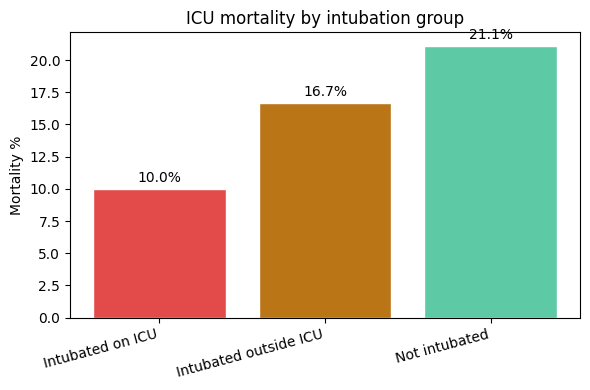

In [16]:
mort_intub = df.groupby('intubation_group').agg(
    patients=('died_on_icu', 'count'),
    deaths=('died_on_icu', 'sum')
).assign(mortality_pct=lambda x: (x['deaths'] / x['patients'] * 100).round(1))

print(mort_intub)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mort_intub.index, mort_intub['mortality_pct'], color=['#e24b4a','#ba7517','#5dcaa5'], edgecolor='white')
ax.set_ylabel('Mortality %')
ax.set_title('ICU mortality by intubation group')
ax.set_xticklabels(mort_intub.index, rotation=15, ha='right')
for i, v in enumerate(mort_intub['mortality_pct']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 4c. qSOFA score and mortality
qSOFA score 3 carries the highest mortality. Validates use of qSOFA as an early warning tool.

       deaths  patients  mortality_pct
qsofa                                 
0           0         8            0.0
1           1         5           20.0
2           2        14           14.3
3           7        19           36.8


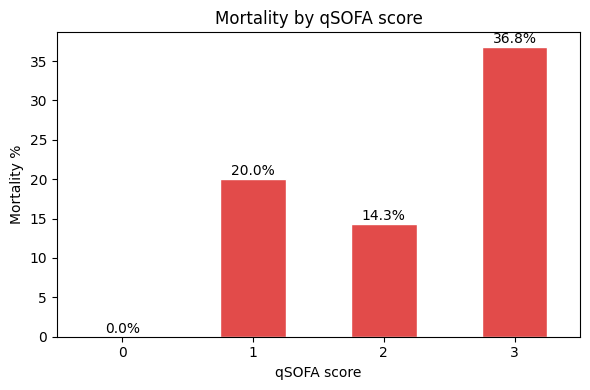

In [17]:
qsofa_mort = df.groupby('qsofa')['died_on_icu'].agg(['sum','count']).assign(
    mortality_pct=lambda x: (x['sum'] / x['count'] * 100).round(1)
).rename(columns={'sum':'deaths','count':'patients'})

print(qsofa_mort)

fig, ax = plt.subplots(figsize=(6, 4))
qsofa_mort['mortality_pct'].plot(kind='bar', ax=ax, color='#e24b4a', edgecolor='white')
ax.set_ylabel('Mortality %')
ax.set_xlabel('qSOFA score')
ax.set_title('Mortality by qSOFA score')
ax.set_xticklabels(qsofa_mort.index, rotation=0)
for i, v in enumerate(qsofa_mort['mortality_pct']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
df['was_intubated'].sum()

np.int64(46)

In [19]:
surgical = df[df['type_of_surgery_grouped'] != 'No Surgery'].shape[0]
print(f"{surgical}/{len(df)} = {surgical/len(df)*100:.1f}%")

101/141 = 71.6%


In [20]:
print(f"Total days in dataset: {len(occupancy)}")
print(f"Days with 0 beds: {(occupancy == 0).sum()}")
print(f"Percentage: {(occupancy == 0).sum() / len(occupancy) * 100:.1f}%")

Total days in dataset: 525
Days with 0 beds: 230
Percentage: 43.8%


In [21]:
df[(df['died_on_icu']) & (df['intubation_group'] == 'Not intubated')][
    ['age_years', 'lead_department', 'type_of_surgery_grouped', 'qsofa']
].sort_values('qsofa', ascending=False)

,age_years,lead_department,type_of_surgery_grouped,qsofa
2,46,Gen_Surg,EGD,3
76,73,Gen_Surg,No Surgery,3
128,41,Gen_Surg,EGD,3
135,51,Gen_Surg,Exploratory Laparotomy,3
87,75,Gen_Surg,Open Prostatectomy,2
140,51,Gen_Surg,Exploratory Laparotomy,1
13,35,Gen_Surg_Trauma,No Surgery,<NA>
33,4,Pediatrics,No Surgery,<NA>
36,26,Internal_Medicine,No Surgery,<NA>
49,25,Internal_Medicine,No Surgery,<NA>


In [22]:
# What % of No Surgery patients had missing qSOFA?
no_surg = df[df['type_of_surgery_grouped'] == 'No Surgery']
print(no_surg['qsofa'].isna().value_counts())
print(f"Missing qSOFA in No Surgery: {no_surg['qsofa'].isna().mean()*100:.1f}%")

qsofa
True     32
False     8
Name: count, dtype: int64
Missing qSOFA in No Surgery: 80.0%


## 5. Summary of Key Findings

| Metric | Value |
|---|---|
| Total ICU admissions | 141 |
| ICU mortality | 25/141 = **17.7%** |
| Referral rate (to KCH) | 14/141 = **9.9%** |
| Intubation rate | 46/141 = **32.6%** |
| Most common procedure | Exploratory Laparotomy (26 cases) |
| Highest dept mortality | Pediatrics **28.6%** |
| qSOFA 3 mortality | **36.8%** |
| Days with 0 beds occupied | 230 / 525 days **(43.8%)** |
| Avg ICU stay (intubated) | **2.9 nights** vs 1.7 (not intubated) |

**Main points:**
- Referral rate 9.9% — predominantly to KCH
- Case mix is 71.6% surgical, dominated by Exploratory Laparotomy
- qSOFA is a valid mortality predictor: score 3 = 36.8% mortality
- 43.8% of days had zero ICU beds occupied — capacity exists
- Non-intubated mortality (21.1%) is explained by a palliated subgroup:
  80% of "No Surgery" deaths had no qSOFA recorded

In [23]:
# Total deaths (non-null cause_of_death)
total_deaths = df['cause_of_death'].notna().sum()

# ICU deaths: died AND had an ICU admission
icu_deaths = df[df['cause_of_death'].notna() & df['icu_admission_date'].notna()].shape[0]

# Percentage
pct = (icu_deaths / total_deaths * 100) if total_deaths > 0 else 0

print(f"Total deaths:  {total_deaths}")
print(f"ICU deaths:    {icu_deaths}")
print(f"% ICU deaths:  {pct:.1f}%")

Total deaths:  21
ICU deaths:    21
% ICU deaths:  100.0%


In [24]:
# Died while still in ICU (no icu_discharge_date, or discharge == hospital_discharge)
icu_deaths_inicu = df[
    df['cause_of_death'].notna() & 
    df['icu_discharge_date'].isna()
].shape[0]

In [25]:
# Check what values discharge_to contains
print(df['discharge_to'].value_counts())
print(df['cause_of_death'].value_counts())

discharge_to
Ward     99
Death    25
Kch      14
Home      3
Name: count, dtype: int64
cause_of_death
Multiorgan Failure                      5
Septic Shock                            2
Hemorrhagic Shock                       2
Typhoid Sepsis                          2
Severe Lung Contusion                   1
Possible Cryptococcal Meningitis        1
Sepsis/Dic                              1
Persistent Lactic Acidosis              1
Pulmonary Edema                         1
Unclear, Brought In Dead                1
Ards                                    1
Preoperative Aspiration (In Theater)    1
Query Renal Malaria                     1
??                                      1
Name: count, dtype: int64


In [26]:
# Deaths = discharge_to == "Death"
total_deaths = (df['discharge_to'] == 'Death').sum()  # 25

# In-ICU death: no ICU discharge date (never left ICU alive)
icu_deaths = df[
    (df['discharge_to'] == 'Death') & 
    (df['icu_discharge_date'].isna())
].shape[0]

# Post-ICU death: made it out of ICU, died on ward
post_icu_deaths = total_deaths - icu_deaths

print(f"Total deaths:       {total_deaths}")
print(f"In-ICU deaths:      {icu_deaths}  ({icu_deaths/total_deaths*100:.1f}%)")
print(f"Post-ICU deaths:    {post_icu_deaths}  ({post_icu_deaths/total_deaths*100:.1f}%)")
print(f"ICU mortality rate: {total_deaths/len(df)*100:.1f}%  (of all 147 patients)")

Total deaths:       25
In-ICU deaths:      0  (0.0%)
Post-ICU deaths:    25  (100.0%)
ICU mortality rate: 17.7%  (of all 147 patients)


In [56]:
# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df_mort = pd.read_excel("../Nkhoma_data/ICU_mortality.xlsx", header=[0, 1])
 
# ── 2. DROP EMPTY ROWS ────────────────────────────────────────────────────────
df_mort = df_mort.dropna(how="all").copy()
 
# ── 3. DROP ARTIFACT / REDUNDANT COLUMNS ─────────────────────────────────────
# Excel multi-header produces blank duplicate columns; also drop raw BD/BA ratios
# since the % versions carry the same info in a more readable form.
drop_cols = [
    ("Pre-ICU (Jan.2022 - July 2023)", "Death/Admission %.1"),  # blank duplicate
    ("Post-ICU (Aug.2023 - Dec.2024)", "Deaths.1"),             # blank duplicate
    ("Pre-ICU vs. Post ICU",           "95% CI"),               # blank; CI split into Lower/Upper
    ("Pre-ICU vs. Post ICU",           "Relative Risk Ratio"),  # blank; values are in "RR"
    ("Pre-ICU vs. Post ICU",           "Before-Death/Admission (BD/BA)"),  # raw ratio; % kept
    ("Pre-ICU vs. Post ICU",           "After-Death/Admission (AD/AA)"),   # raw ratio; % kept
]
df_mort = df_mort.drop(columns=[c for c in drop_cols if c in df_mort.columns])

# ── 4. FLATTEN MULTI-INDEX → SNAKE_CASE ──────────────────────────────────────
df_mort.columns = ["_".join(str(lvl) for lvl in col).strip() for col in df_mort.columns]
 
rename_map = {
    "Unnamed: 0_level_0_Unnamed: 0_level_1":            "ward",
    "Pre-ICU (Jan.2022 - July 2023)_Admissions":        "pre_admissions",
    "Pre-ICU (Jan.2022 - July 2023)_Deaths":            "pre_deaths",
    "Pre-ICU (Jan.2022 - July 2023)_Death/Admission %": "pre_death_pct",
    "Post-ICU (Aug.2023 - Dec.2024)_Admissions":        "post_admissions",
    "Post-ICU (Aug.2023 - Dec.2024)_Deaths":            "post_deaths",
    "Post-ICU (Aug.2023 - Dec.2024)_Death/Admission %": "post_death_pct",
    "Pre-ICU vs. Post ICU_Change %":                    "change_pct",
    "Pre-ICU vs. Post ICU_BD/BA[%]":                    "pre_death_admission_pct",
    "Pre-ICU vs. Post ICU_AD/AA[%]":                    "post_death_admission_pct",
    "Pre-ICU vs. Post ICU_RR":                          "rr",
    "Pre-ICU vs. Post ICU_log(RR)":                     "log_rr",
    "Pre-ICU vs. Post ICU_SE of log(RR)":               "se_log_rr",
    "Pre-ICU vs. Post ICU_z":                           "z_stat",
    "Pre-ICU vs. Post ICU_Lower 95% CI":                "ci_lower",
    "Pre-ICU vs. Post ICU_Upper 95% CI":                "ci_upper",
    "Pre-ICU vs. Post ICU_p-values (Wald test)":        "p_value",
}
df_mort = df_mort.rename(columns=rename_map)
# Double space in "Change  %" — rename the surviving unmatched column
df_mort = df_mort.rename(columns={"Pre-ICU vs. Post ICU_Change  %": "change_pct"})
df_mort = df_mort.rename(columns={"Pre-ICU vs. Post ICU_P-value": "p_value_old"})
df_mort["p_value"] = pd.to_numeric(df_mort["p_value"], errors="coerce")
# Drop the duplicate p_value column (keep first)
df_mort = df_mort.loc[:, ~df_mort.columns.duplicated()]

# Drop any rows where ward is NaN (trailing empty Excel rows)
df_mort = df_mort.dropna(subset=["ward"]).reset_index(drop=True)

# Replace "-" strings with NaN before casting (Private Ward p-value)
df_mort = df_mort.replace("-", np.nan).infer_objects(copy=False)

# ── 5. SEPARATE TOTAL ROW ─────────────────────────────────────────────────────
df_total = df_mort[df_mort["ward"] == "TOTAL"].copy()
df_mort       = df_mort[df_mort["ward"] != "TOTAL"].reset_index(drop=True)

# ── 6. CAST TYPES ────────────────────────────────────────────────────────────
# Int64 (nullable) handles Private Ward's zero-death rows without coercing to float
int_cols = ["pre_admissions", "pre_deaths", "post_admissions", "post_deaths"]
df_mort[int_cols] = df_mort[int_cols].astype("Int64")
 
float_cols = [
    "pre_death_pct", "post_death_pct", "change_pct",
    "pre_death_admission_pct", "post_death_admission_pct",
    "rr", "log_rr", "se_log_rr", "z_stat",
    "ci_lower", "ci_upper", "p_value",
]
df_mort[float_cols] = df_mort[float_cols].astype(float)
df_mort

/tmp/ipykernel_4022/2622616798.py:54: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mort = df_mort.replace("-", np.nan).infer_objects(copy=False)


,ward,pre_admissions,pre_deaths,pre_death_pct,post_admissions,post_deaths,post_death_pct,change_pct,p_value_old,pre_death_admission_pct,post_death_admission_pct,rr,log_rr,se_log_rr,z_stat,ci_lower,ci_upper,p_value
0,Maternity Ward,6701,4,0.1,6180,1,0.02,-72.9,0.370,0.059693,0.016181,0.271076,-1.305356,1.117895,-1.167691,0.030305,2.424725,0.242931
1,Pediatric Ward,3728,108,2.9,4061,100,2.50,-15.0,0.260,2.896996,2.462448,0.850000,-0.162518,0.136912,-1.187032,0.649947,1.111631,0.235215
2,Medical Ward,2649,265,10.0,2783,226,8.10,-18.8,0.016,10.003775,8.120733,0.811767,-0.208542,0.086380,-2.414235,0.685335,0.961523,0.015768
3,Surgical Ward,2748,32,1.2,3095,23,0.70,-36.2,0.100,1.164483,0.743134,0.638166,-0.449156,0.272105,-1.650671,0.374381,1.087814,0.098806
4,Private Ward,102,0,0.0,76,0,0.00,0.0,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
print(df_mort.columns.tolist())

['ward', 'pre_admissions', 'pre_deaths', 'pre_death_pct', 'post_admissions', 'post_deaths', 'post_death_pct', 'Pre-ICU vs. Post ICU_Change  %', 'p_value', 'pre_death_admission_pct', 'post_death_admission_pct', 'rr', 'log_rr', 'se_log_rr', 'z_stat', 'ci_lower', 'ci_upper', 'p_value']


KeyError: "['change_pct'] not in index"

In [ ]:


# 2a. Separate summary row from ward-level rows
df_total = df[df["Ward"] == "TOTAL"].copy()
df = df[df["Ward"] != "TOTAL"].copy().reset_index(drop=True)

# 2b. Fix Private Ward: 0 admissions leads to undefined risk — mark explicitly
df.loc[df["Ward"] == "Private Ward", ["Relative_Risk", "P_value"]] = np.nan

# 2c. Parse confidence interval into two numeric columns
def parse_ci(ci_str):
    if pd.isna(ci_str) or ci_str is None:
        return np.nan, np.nan
    lo, hi = ci_str.split("-")
    return float(lo), float(hi)

df[["CI_lower", "CI_upper"]] = df["CI_95"].apply(
    lambda x: pd.Series(parse_ci(x))
)
df_total[["CI_lower", "CI_upper"]] = df_total["CI_95"].apply(
    lambda x: pd.Series(parse_ci(x))
)
df.drop(columns="CI_95", inplace=True)
df_total.drop(columns="CI_95", inplace=True)

# 2d. Cast types explicitly
int_cols = ["Pre_Admissions", "Pre_Deaths", "Post_Admissions", "Post_Deaths"]
df[int_cols] = df[int_cols].astype(int)

float_cols = [
    "Pre_Death_Pct", "Post_Death_Pct", "Change_Pct",
    "Relative_Risk", "P_value",
    "BD_BA", "BD_BA_Pct", "AD_AA", "AD_AA_Pct",
    "CI_lower", "CI_upper",
]
df[float_cols] = df[float_cols].astype(float)

# 2e. Add a significance flag (α = 0.05)
df["Significant"] = df["P_value"] < 0.05

# 2f. Derived sanity check: recompute death % from raw counts
df["Pre_Death_Pct_check"]  = (df["Pre_Deaths"]  / df["Pre_Admissions"]  * 100).round(2)
df["Post_Death_Pct_check"] = (df["Post_Deaths"] / df["Post_Admissions"] * 100).round(2)

# ── 3. QUICK SUMMARY ─────────────────────────────────────────────────────────
print("=== Cleaned ward-level data ===")
print(df[["Ward", "Pre_Admissions", "Pre_Deaths", "Pre_Death_Pct",
          "Post_Admissions", "Post_Deaths", "Post_Death_Pct",
          "Change_Pct", "Relative_Risk", "CI_lower", "CI_upper",
          "P_value", "Significant"]].to_string(index=False))

print("\n=== TOTAL row ===")
print(df_total[["Ward", "Pre_Admissions", "Pre_Deaths",
                "Post_Admissions", "Post_Deaths",
                "Change_Pct", "Relative_Risk", "CI_lower", "CI_upper",
                "P_value"]].to_string(index=False))

print("\n=== dtypes ===")
print(df.dtypes)

print("\n=== Missing values ===")
print(df.isnull().sum())